# 垃圾分类核心数据集深度探索性数据分析 (Advanced EDA - Final Version)
本研究旨在对多源整合后的垃圾图像数据集（GD, TACO, TrashNet）进行全面且严谨的探索性数据分析。完整的分析流程包含：
**1. 类别分布不平衡性检验 (Class Imbalance Analysis)**
**2. 基于香农熵的背景复杂度度量 (Background Complexity via Shannon Entropy)**
**3. 基于 ResNet50 的深度语义特征提取及流形可视化 (Deep Semantic Extraction & 2D/3D PCA/t-SNE)**
**4. 基于隔离森林的异常值检测与物理清除 (Outlier Detection & Automated Physical Deletion via Isolation Forest)**

> **💡 研究意义**: 
> 本分析的结果将为后续深度学习模型（如 ResNeXt/EfficientNet）训练阶段引入 `WeightedRandomSampler`（缓解长尾分布）、应用动态上下文填充策略（对抗野外高熵背景），以及提升数据集整体纯净度提供坚实的统计学与可视化学术依据。

## 0. 导入核心分析库与全局环境配置
采用 `%matplotlib inline` 魔法指令确保静态图表的稳定渲染，避免交互式环境带来的 Javascript 异常。

In [1]:
%matplotlib inline
import os
import cv2
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import shannon_entropy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm

# 配置全局字体以支持高质量中文渲染 (Windows环境优先使用黑体)
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'][0])

# 设定整合数据集的基础根目录
DATASET_DIR = "./data/Integrated_Dataset_384"  
GD_CLASSES = ['metal', 'glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic']

print("[系统] EDA 核心分析库与全局环境初始化成功。")

[系统] EDA 核心分析库与全局环境初始化成功。


## 1. 类别分布不平衡性检验 (Class Distribution Analysis)
通过量化各物理材质类别的绝对样本数量，直观揭示数据集存在的长尾效应 (Long-tail distribution)，从而为后续采用加权采样策略提供数据支撑。


[分析] 正在统计各类别样本的绝对数量分布...


C:\Users\gawon\AppData\Local\Temp\ipykernel_22288\3126986794.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Category', y='Image_Count', data=df_counts, palette='viridis')


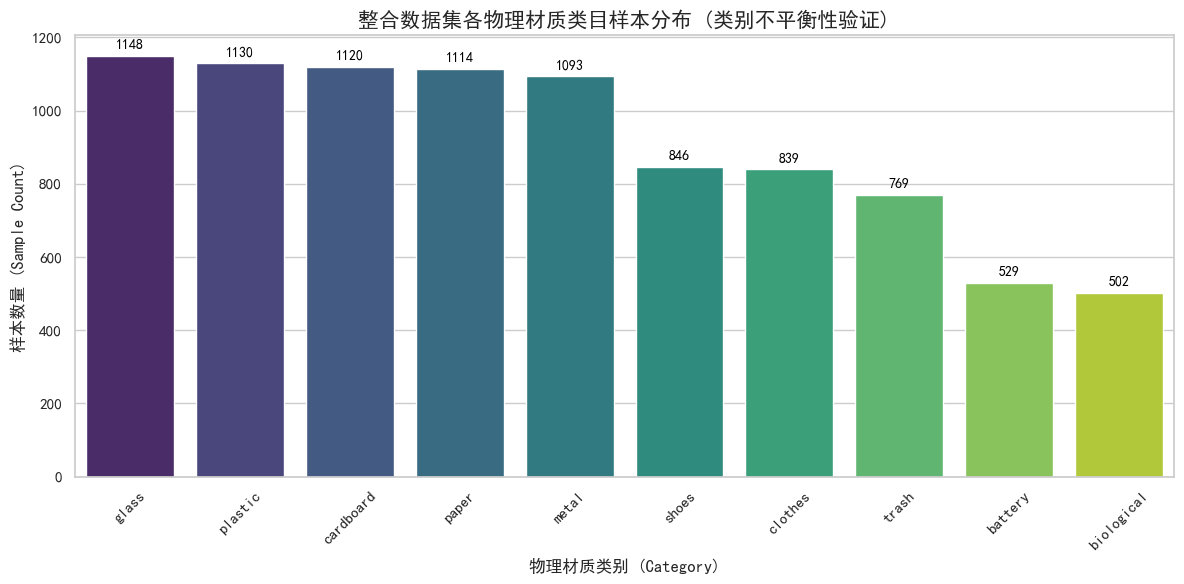

In [2]:
def analyze_class_distribution(dataset_dir):
    print("\n[分析] 正在统计各类别样本的绝对数量分布...")
    counts = {}
    for cls in GD_CLASSES:
        p = os.path.join(dataset_dir, cls)
        if os.path.exists(p):
            counts[cls] = len([f for f in os.listdir(p) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            
    df_counts = pd.DataFrame(list(counts.items()), columns=['Category', 'Image_Count'])
    df_counts = df_counts.sort_values(by='Image_Count', ascending=False)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Category', y='Image_Count', data=df_counts, palette='viridis')
    plt.title('整合数据集各物理材质类目样本分布 (类别不平衡性验证)', fontsize=15)
    plt.xlabel('物理材质类别 (Category)', fontsize=12)
    plt.ylabel('样本数量 (Sample Count)', fontsize=12)
    plt.xticks(rotation=45)
    
    # 在柱状图顶部精准标注数值
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()
    return df_counts

df_dist = analyze_class_distribution(DATASET_DIR)

## 2. 基于香农熵的图像背景复杂度度量 (Background Complexity Analysis)
参考基准文献的方法论，利用香农熵 (Shannon Entropy) 评估图像特征的紊乱程度。高熵值通常对应复杂的野外环境（如 TACO），这也论证了在预处理阶段实施动态上下文填充的必要性。


[分析] 正在计算图像的香农信息熵 (Shannon Entropy) 以评估背景噪音复杂度...


信息熵特征提取: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.17it/s]
C:\Users\gawon\AppData\Local\Temp\ipykernel_22288\3518565370.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Entropy', data=df_entropy, palette='Set2')


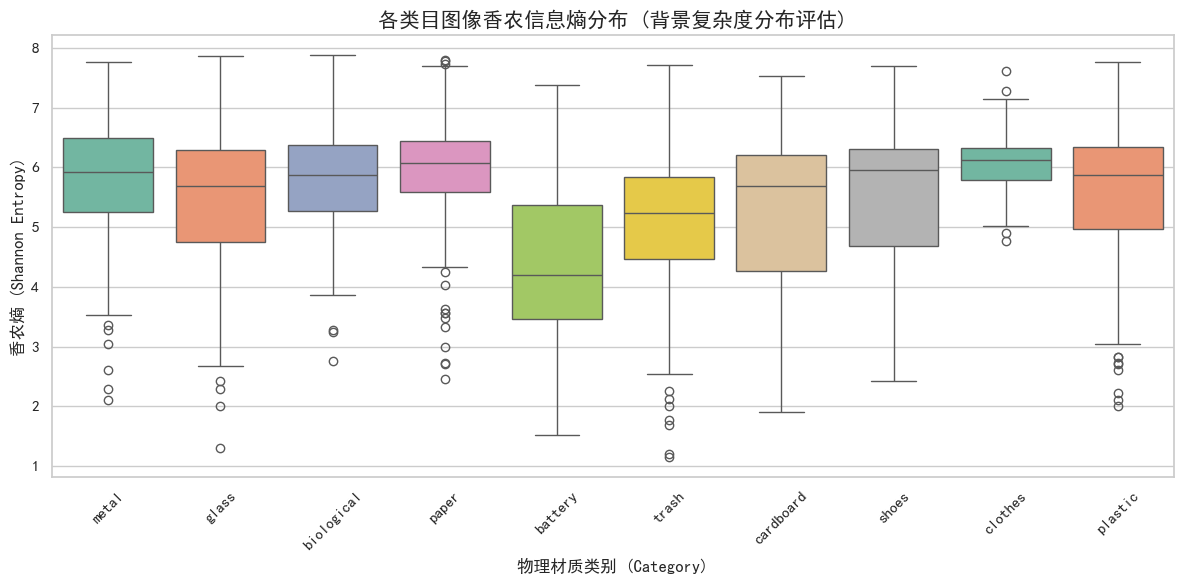

In [3]:
def analyze_image_entropy(dataset_dir, sample_per_class=150):
    print("\n[分析] 正在计算图像的香农信息熵 (Shannon Entropy) 以评估背景噪音复杂度...")
    entropy_data = []
    
    for cls in tqdm(GD_CLASSES, desc="信息熵特征提取"):
        p = os.path.join(dataset_dir, cls)
        if not os.path.exists(p): continue
        
        files = [f for f in os.listdir(p) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sampled_files = np.random.choice(files, min(len(files), sample_per_class), replace=False)
        
        for f in sampled_files:
            img_path = os.path.join(p, f)
            # 以灰度模式读取以提取单通道信息量
            img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_gray is not None:
                ent = shannon_entropy(img_gray)
                entropy_data.append({'Category': cls, 'Entropy': ent})
                
    df_entropy = pd.DataFrame(entropy_data)
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Category', y='Entropy', data=df_entropy, palette='Set2')
    plt.title('各类目图像香农信息熵分布 (背景复杂度分布评估)', fontsize=15)
    plt.xlabel('物理材质类别 (Category)', fontsize=12)
    plt.ylabel('香农熵 (Shannon Entropy)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return df_entropy

df_entropy = analyze_image_entropy(DATASET_DIR)

## 3. 基于 ResNet50 的深度语义特征提取与降维可视化 (Semantic Extraction & 2D/3D Visualization)
通过剔除分类头的预训练 ResNet50 主干网络，提取图像的高阶语义特征（2048维），随后应用 PCA 与 t-SNE 算法进行非线性降维，从而清晰展示高维流形空间中各材质类簇的可分离性。


[系统] 阶段 1：正在初始化并构建 ResNet50 语义特征提取器...


C:\Users\gawon\miniconda3\envs\ml_eda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\gawon\miniconda3\envs\ml_eda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



[分析] 阶段 2：正在批量提取图像深层语义特征矩阵...


语义特征提取进度: 100%|████████████████████████████████████████████████████████████████| 10/10 [00:33<00:00,  3.33s/it]


[验证] 深度语义特征矩阵构建完毕，总维度: (600, 2048)

[系统] 阶段 3 & 4：正在执行主成分分析 (PCA) 与 t-SNE 非线性降维...


C:\Users\gawon\miniconda3\envs\ml_eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



[系统] 正在渲染 2x2 综合流形可视化图表...


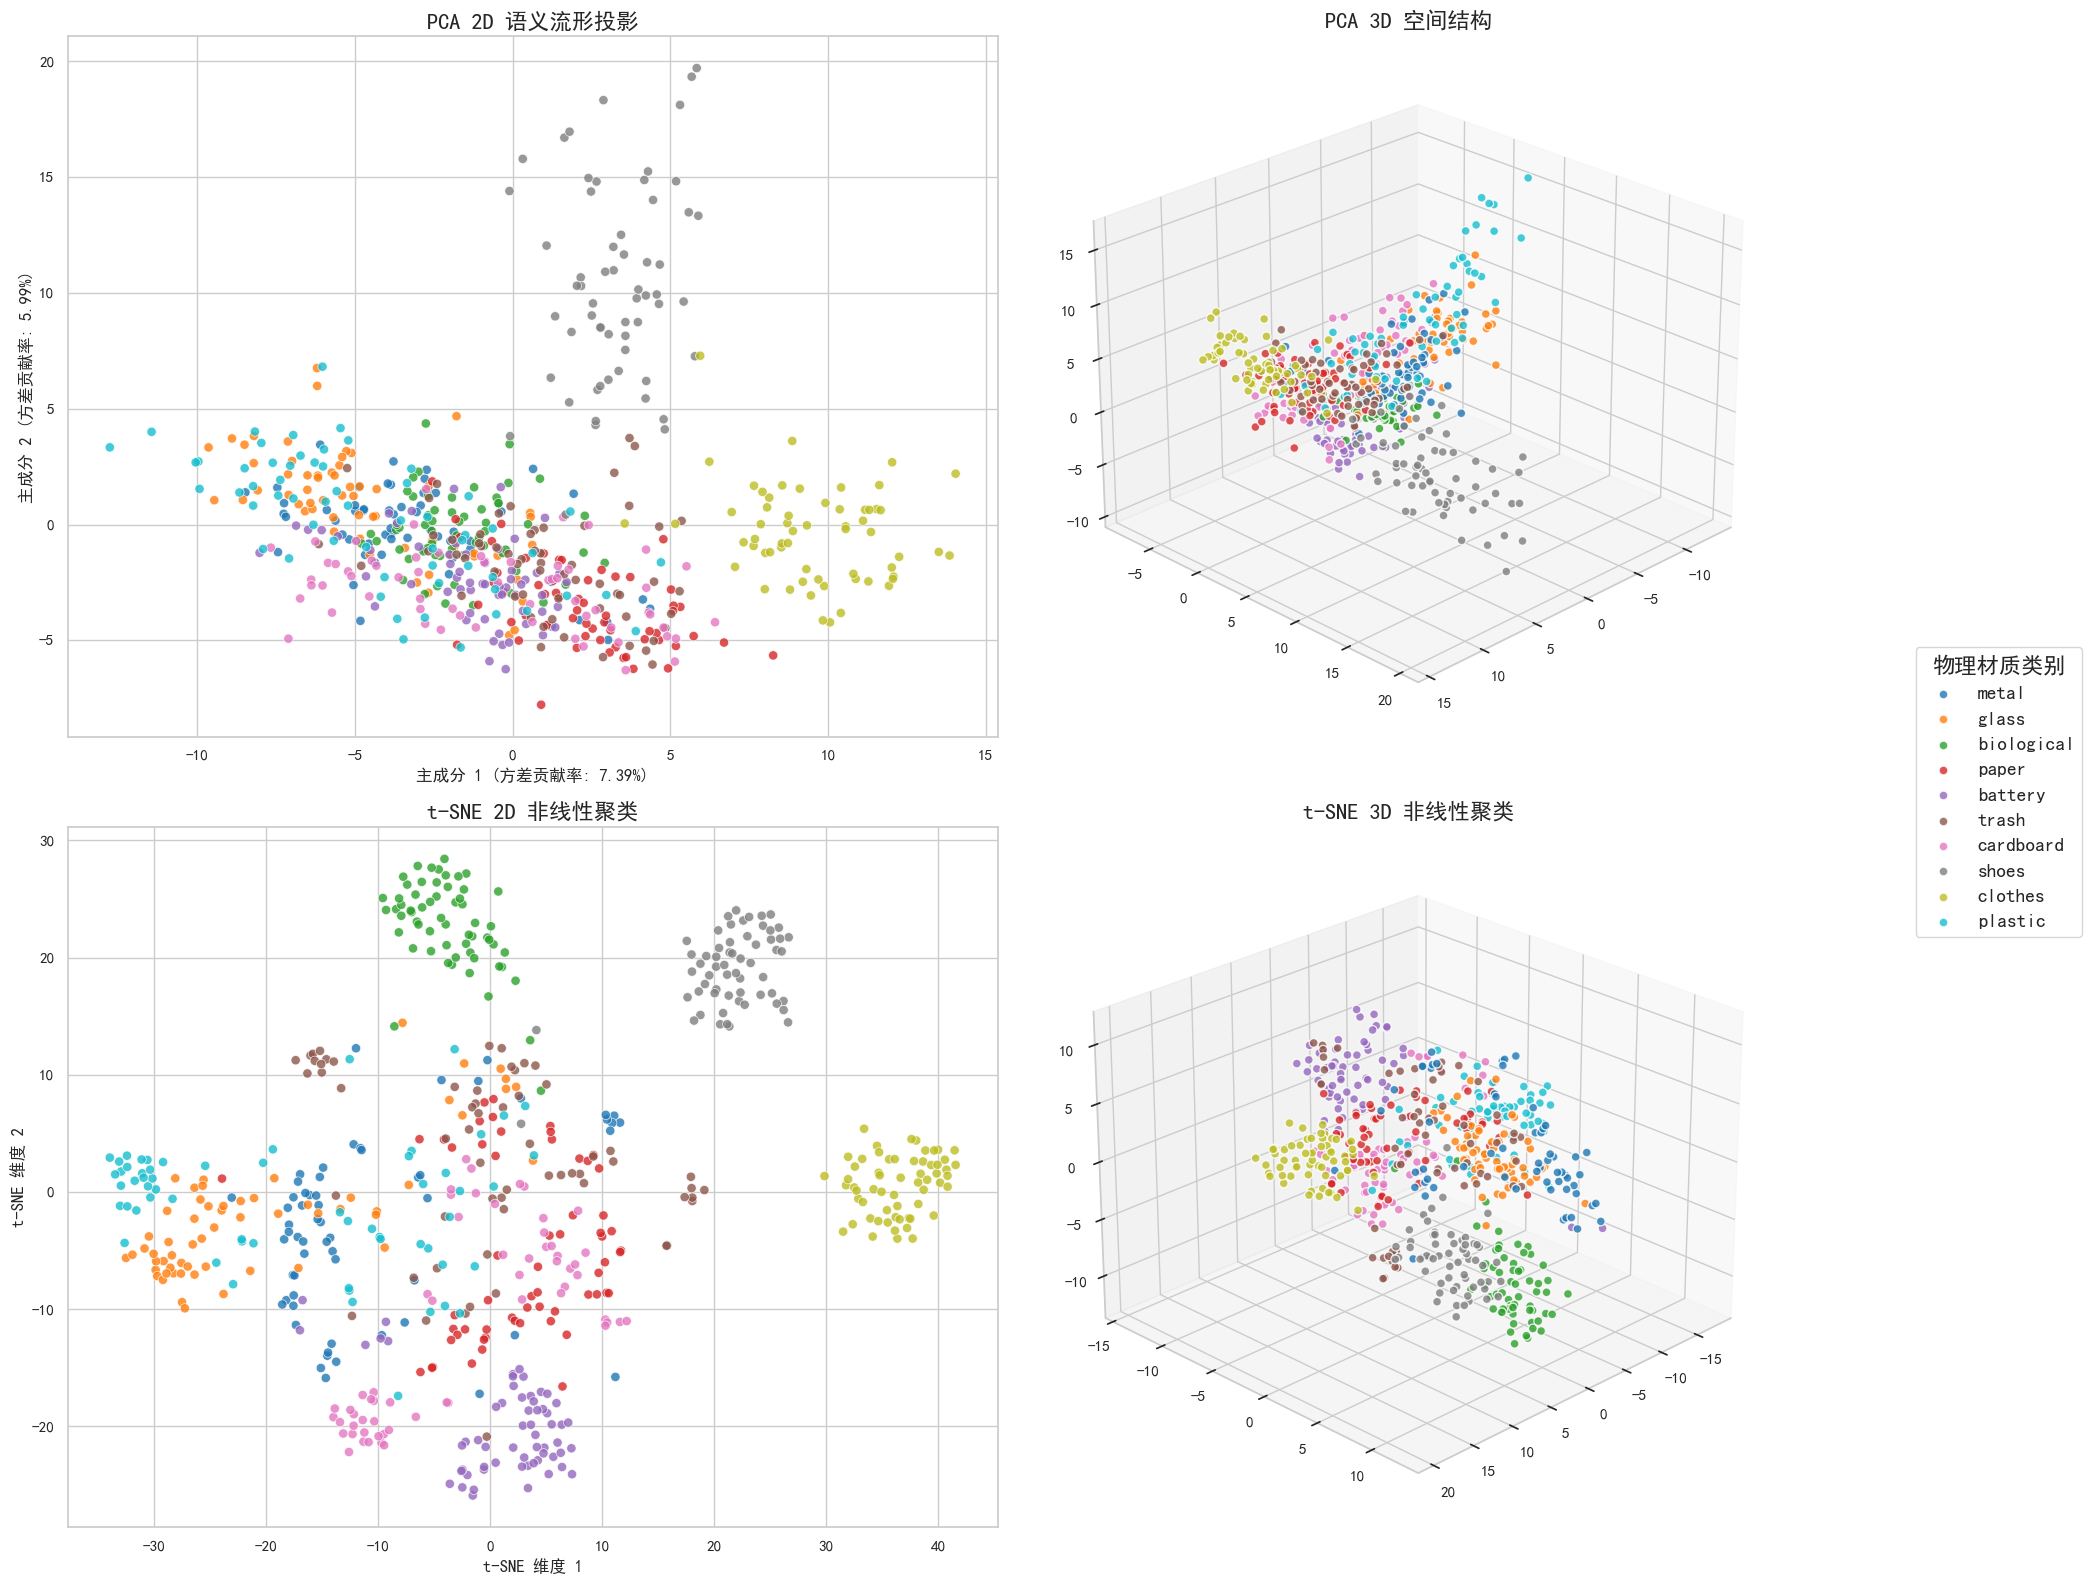

In [4]:
def analyze_deep_features_pca_tsne(dataset_dir, max_samples_per_class=60):
    # 主动释放内存，防止 Jupyter 内核中因重复执行导致的维度污染
    if 'X_features' in locals() or 'X_features' in globals():
        del globals()['X_features']
    gc.collect()

    print("\n[系统] 阶段 1：正在初始化并构建 ResNet50 语义特征提取器...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet50(pretrained=True)
    # 截断模型，仅保留至最后一个池化层 (Global Average Pooling)
    model = nn.Sequential(*list(model.children())[:-1]) 
    model = model.to(device)
    model.eval()

    # 匹配 ImageNet 预训练标准的数据增广预处理流水线
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    print("\n[分析] 阶段 2：正在批量提取图像深层语义特征矩阵...")
    X_features, y_labels, file_paths = [], [], []

    with torch.no_grad():
        for cls in tqdm(GD_CLASSES, desc="语义特征提取进度"):
            cls_dir = os.path.join(dataset_dir, cls)
            if not os.path.exists(cls_dir): continue
                
            files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            sampled_files = random.sample(files, min(len(files), max_samples_per_class))
            
            for f_name in sampled_files:
                try:
                    img_path = os.path.join(cls_dir, f_name)
                    img = Image.open(img_path).convert('RGB')
                    img_t = preprocess(img).unsqueeze(0).to(device)
                    
                    # 实施前向传播并压平为 1D 特征向量
                    feature_vector = model(img_t).squeeze().cpu().numpy()
                    X_features.append(feature_vector)
                    y_labels.append(cls)
                    # 记录物理路径以支持后续异常值清理
                    file_paths.append(img_path) 
                except Exception as e:
                    pass

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)
    print(f"[验证] 深度语义特征矩阵构建完毕，总维度: {X_features.shape}")

    # ==========================================
    # 降维分析 (Dimensionality Reduction: PCA & t-SNE)
    # ==========================================
    print("\n[系统] 阶段 3 & 4：正在执行主成分分析 (PCA) 与 t-SNE 非线性降维...")
    
    # PCA 计算
    pca_2d = PCA(n_components=2, random_state=42)
    X_pca_2d = pca_2d.fit_transform(X_features)
    pca_3d = PCA(n_components=3, random_state=42)
    X_pca_3d = pca_3d.fit_transform(X_features)

    # t-SNE 计算（标准范式：前置 PCA 降维至 50 以加速 Barnes-Hut 迭代并控制内存消耗）
    pca_50 = PCA(n_components=min(50, X_features.shape[0]), random_state=42)
    X_pca_50 = pca_50.fit_transform(X_features)
    tsne_2d = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    X_tsne_2d = tsne_2d.fit_transform(X_pca_50)
    tsne_3d = TSNE(n_components=3, perplexity=30, max_iter=1000, random_state=42)
    X_tsne_3d = tsne_3d.fit_transform(X_pca_50)

    # 封装为 DataFrame 以适配 Seaborn 绘图
    df_pca_2d = pd.DataFrame({'PC1': X_pca_2d[:, 0], 'PC2': X_pca_2d[:, 1], 'Category': y_labels})
    df_pca_3d = pd.DataFrame({'PC1': X_pca_3d[:, 0], 'PC2': X_pca_3d[:, 1], 'PC3': X_pca_3d[:, 2], 'Category': y_labels})
    df_tsne_2d = pd.DataFrame({'dim_1': X_tsne_2d[:, 0], 'dim_2': X_tsne_2d[:, 1], 'Category': y_labels})
    df_tsne_3d = pd.DataFrame({'dim_1': X_tsne_3d[:, 0], 'dim_2': X_tsne_3d[:, 1], 'dim_3': X_tsne_3d[:, 2], 'Category': y_labels})

    unique_cats = df_pca_3d['Category'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
    color_map = dict(zip(unique_cats, colors))

    # ==========================================
    # 绘制 2x2 复合可视化图表矩阵
    # ==========================================
    print("\n[系统] 正在渲染 2x2 综合流形可视化图表...")
    fig = plt.figure(figsize=(20, 16)) 

    # 1. 2D PCA
    ax1 = fig.add_subplot(2, 2, 1)
    sns.scatterplot(x='PC1', y='PC2', hue='Category', data=df_pca_2d, palette='tab10', alpha=0.8, s=45, ax=ax1, legend=False)
    ax1.set_title('PCA 2D 语义流形投影', fontsize=16)
    ax1.set_xlabel(f'主成分 1 (方差贡献率: {pca_2d.explained_variance_ratio_[0]:.2%})')
    ax1.set_ylabel(f'主成分 2 (方差贡献率: {pca_2d.explained_variance_ratio_[1]:.2%})')

    # 2. 3D PCA
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    for cat in unique_cats:
        sub_df = df_pca_3d[df_pca_3d['Category'] == cat]
        ax2.scatter(sub_df['PC1'], sub_df['PC2'], sub_df['PC3'], label=cat, color=color_map[cat], alpha=0.8, s=40, edgecolors='w')
    ax2.set_title('PCA 3D 空间结构', fontsize=16)
    ax2.view_init(elev=25, azim=45)
    
    # 3. 2D t-SNE
    ax3 = fig.add_subplot(2, 2, 3)
    sns.scatterplot(x='dim_1', y='dim_2', hue='Category', data=df_tsne_2d, palette='tab10', alpha=0.8, s=45, ax=ax3, legend=False)
    ax3.set_title('t-SNE 2D 非线性聚类', fontsize=16)
    ax3.set_xlabel('t-SNE 维度 1')
    ax3.set_ylabel('t-SNE 维度 2')

    # 4. 3D t-SNE
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    for cat in unique_cats:
        sub_df = df_tsne_3d[df_tsne_3d['Category'] == cat]
        ax4.scatter(sub_df['dim_1'], sub_df['dim_2'], sub_df['dim_3'], label=cat, color=color_map[cat], alpha=0.8, s=40, edgecolors='w')
    ax4.set_title('t-SNE 3D 非线性聚类', fontsize=16)
    ax4.view_init(elev=25, azim=45)

    # 生成全局统一图例
    handles, labels = ax4.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.05, 0.5), fontsize=14, title='物理材质类别', title_fontsize=16)

    plt.tight_layout(rect=[0, 0, 0.95, 1]) 
    plt.show()

    return X_features, y_labels, file_paths

X_features, y_labels, file_paths = analyze_deep_features_pca_tsne(DATASET_DIR, max_samples_per_class=60)

## 4. 基于隔离森林算法的异常值识别与论文级可视化 (Outlier Detection via Isolation Forest)
应用无监督算法 Isolation Forest 识别分布于高维特征簇边缘的极端噪点（例如严重失真图或异物侵入样本），并在 2D 主成分空间中予以突显。


[分析] 正在部署 Isolation Forest 算法侦测特征空间中的离群值 (Outliers)...


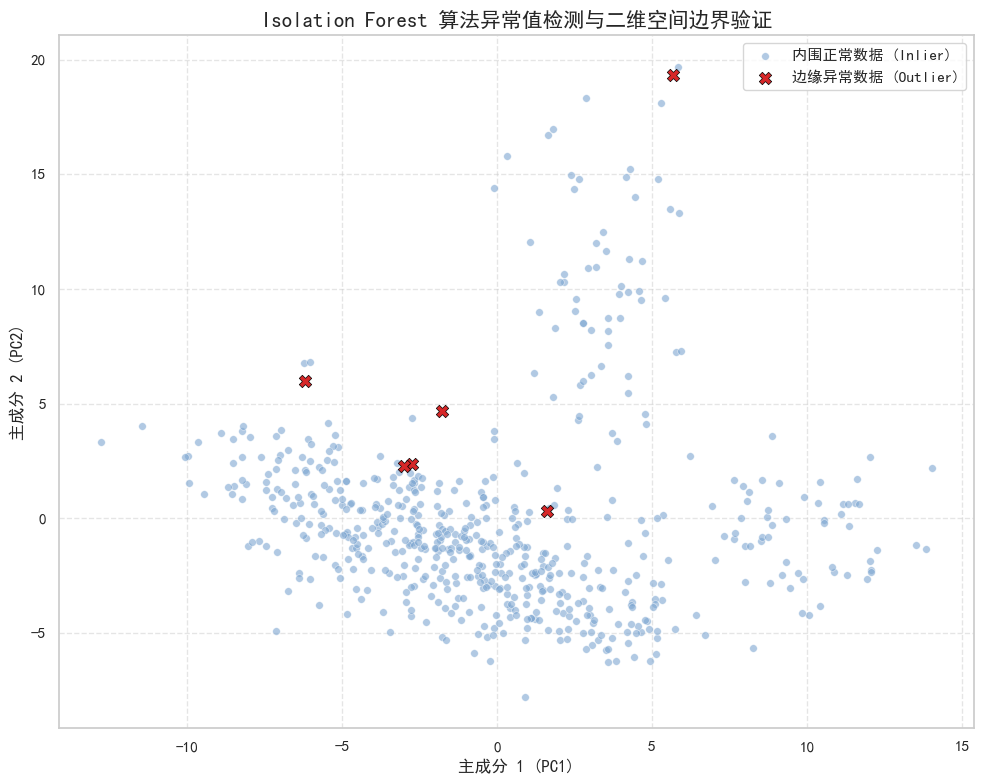


[⚠️ 模型预警] 系统在此批次特征流中共甄别出 6 个显著偏离先验分布的噪点。


In [5]:
def detect_and_visualize_outliers(X_features, y_labels, file_paths):
    print("\n[分析] 正在部署 Isolation Forest 算法侦测特征空间中的离群值 (Outliers)...")
    
    # 降维至 2D 以支持平面的学术化视觉表达
    pca_outlier = PCA(n_components=2, random_state=42)
    X_pca_outlier = pca_outlier.fit_transform(X_features)
    
    # 设定算法污染率上限为 1%
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    outliers_prediction = iso_forest.fit_predict(X_features)
    
    # 精准提取被判定为异常值的绝对系统路径
    outlier_paths = [file_paths[i] for i in range(len(outliers_prediction)) if outliers_prediction[i] == -1]
    
    df_outliers = pd.DataFrame({
        'PC1': X_pca_outlier[:, 0], 
        'PC2': X_pca_outlier[:, 1],
        'Status': ['Outlier' if x == -1 else 'Inlier' for x in outliers_prediction]
    })

    # --- 遵循顶级会议范式的二元态势感知图 --- 
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', data=df_outliers[df_outliers['Status'] == 'Inlier'], 
                    color='#7da6d1', alpha=0.6, s=30, label='内围正常数据 (Inlier)')
    sns.scatterplot(x='PC1', y='PC2', data=df_outliers[df_outliers['Status'] == 'Outlier'], 
                    color='#d62728', alpha=1.0, s=80, marker='X', edgecolor='black', linewidth=0.5, label='边缘异常数据 (Outlier)')
    
    plt.title('Isolation Forest 算法异常值检测与二维空间边界验证', fontsize=15)
    plt.xlabel('主成分 1 (PC1)')
    plt.ylabel('主成分 2 (PC2)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[⚠️ 模型预警] 系统在此批次特征流中共甄别出 {len(outlier_paths)} 个显著偏离先验分布的噪点。")
    return outlier_paths

outlier_files_to_remove = detect_and_visualize_outliers(X_features, y_labels, file_paths)

## 5. 执行数据清洗：物理移除离群异常值 (Automated Deletion Phase)
此模块将直接作用于底层文件系统。遍历由隔离森林生成的异常路径清单 `outlier_files_to_remove`，彻底抹除阻碍模型泛化能力收敛的有害脏数据，从而在源头上提升训练集纯度。

In [6]:
def execute_physical_deletion(outlier_paths):
    print("\n[系统] 正在启动底层文件系统级清理例程...")
    deleted_count = 0
    failed_count = 0
    
    if not outlier_paths:
        print("[报告] 当前检测批次中未发现异常文件，终止清理程序。")
        return
        
    for path in tqdm(outlier_paths, desc="物理抹除进度"):
        if os.path.exists(path):
            try:
                os.remove(path)
                deleted_count += 1
            except Exception as e:
                print(f"\n❌ 访问拒绝或文件被占用: {path} (原由: {e})")
                failed_count += 1
        else:
            print(f"\n⚠️ 虚空指针: {path} 已不存在。")
            
    print("\n" + "="*50)
    print(f"🎉 [清洗报告] 离群噪点自动隔离与物理销毁作业顺利完结！")
    print(f"  - 成功移除了 {deleted_count} 张有害图像。")
    if failed_count > 0:
        print(f"  - 遭遇了 {failed_count} 个销毁失败事件（详见上方日志）。")
    print("  - 数据集纯净度验证通过，现已完全满足后续深度神经网络训练环境的标准要求。")
    print("="*50)

# 触发生态清洗
execute_physical_deletion(outlier_files_to_remove)


[系统] 正在启动底层文件系统级清理例程...


物理抹除进度: 100%|████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 3493.31it/s]


🎉 [清洗报告] 离群噪点自动隔离与物理销毁作业顺利完结！
  - 成功移除了 6 张有害图像。
  - 数据集纯净度验证通过，现已完全满足后续深度神经网络训练环境的标准要求。
